# DVS128 Benchmark: EvT-OG vs TimeSformer

This notebook builds a benchmark comparison between the two pipelines used in this project:

- **EvT-OG**: event-native transformer working on sparse event-frame chunks.
- **TimeSformer**: video transformer trained on E2VID-reconstructed PNG clips.

The benchmark is structured to stay defensible:

- the **main comparison** is the one that uses the **same test split** for both models;
- validation curves and validation metrics are shown as training diagnostics;
- resource statistics are reported only where they are actually available from the current code and artifacts.

The notebook is intended to answer these questions:

- How do the two models compare on **top-1** and **top-5** accuracy?
- What happens on **validation** versus **test**?
- Which classes are confused on the shared test split?
- What do the validation curves look like?
- How do parameters, FLOPs, latency, activated patches, and GPU memory compare where measurable?

## 1. Paths and experiment scope

This cell defines the local paths used by the notebook and prints a short summary of the artifacts that will be compared.

Important interpretation rule:

- **Fair benchmark result** = metrics computed on the same official test split for both models.
- Validation results are still useful, but they are secondary to the shared-test comparison.

In [1]:
from __future__ import annotations

import contextlib
import io
import json
import os
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import confusion_matrix

/home/ppfsa/miniconda3/envs/tese_py37/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ROOT = Path('/home/ppfsa/TESE')
DEV_ROOT = ROOT / 'dev'
EVT_ROOT = DEV_ROOT / 'EvT-OG'
TS_ROOT = DEV_ROOT / 'TimeSformer'

EVT_MODEL_DIR = EVT_ROOT / 'pretrained_models' / 'DVS128_11_24ms_dwn'
EVT_METRICS_CSV = EVT_MODEL_DIR / 'train_log' / 'version_0' / 'metrics.csv'

TS_CFG = TS_ROOT / 'configs' / 'DVS128' / 'TimeSformer_divST_8x1_128_finetune.yaml'
TS_OUTPUT_DIR = TS_ROOT / 'outputs' / 'dvs128_all_samples_finetune_earlystop'
TS_STDOUT_LOG = TS_OUTPUT_DIR / 'stdout.log'
TS_CHECKPOINT_DIR = TS_OUTPUT_DIR / 'checkpoints'

TS_MANIFEST_DIR = DEV_ROOT / 'datasets' / 'timesformer' / 'DVS128' / 'manifests' / 'all_samples_8f'
RAW_ROOT = DEV_ROOT / 'datasets' / 'raw' / 'DVS128'
GESTURE_MAPPING_CSV = RAW_ROOT / 'gesture_mapping.csv'

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
RUN_EVT_COMPLEXITY = True

gesture_df = pd.read_csv(GESTURE_MAPPING_CSV)
CLASS_NAMES = gesture_df['action'].tolist()
DISPLAY_CLASS_NAMES = [name.strip().replace('_', ' ').title() for name in CLASS_NAMES]

print('Device:', DEVICE)
print('EvT model dir:', EVT_MODEL_DIR)
print('TimeSformer output dir:', TS_OUTPUT_DIR)
print('TimeSformer manifests:', TS_MANIFEST_DIR)

Device: cuda:0
EvT model dir: /home/ppfsa/TESE/dev/EvT-OG/pretrained_models/DVS128_11_24ms_dwn
TimeSformer output dir: /home/ppfsa/TESE/dev/TimeSformer/outputs/dvs128_all_samples_finetune_earlystop
TimeSformer manifests: /home/ppfsa/TESE/dev/datasets/timesformer/DVS128/manifests/all_samples_8f


## 2. Artifact inspection and run selection

Results for Timesformer (10epochs fine-tune on the test split same split as EVT):

In [3]:
def parse_json_stats_log(path: Path) -> list[dict]:
    records = []
    for line in path.read_text().splitlines():
        if 'json_stats:' not in line:
            continue
        payload = line.split('json_stats:', 1)[1].strip()
        try:
            records.append(json.loads(payload))
        except json.JSONDecodeError:
            continue
    return records


def latest_timesformer_run(records: list[dict]) -> list[dict]:
    test_final_idx = [i for i, r in enumerate(records) if r.get('split') == 'test_final']
    if not test_final_idx:
        raise RuntimeError('No test_final record found in TimeSformer stdout.log')
    end = test_final_idx[-1]
    start = test_final_idx[-2] + 1 if len(test_final_idx) > 1 else 0
    return records[start : end + 1]


def manifest_size(path: Path) -> int:
    return max(0, sum(1 for _ in path.open('r')) - 1)


ts_all_records = parse_json_stats_log(TS_STDOUT_LOG)
ts_run_records = latest_timesformer_run(ts_all_records)

manifest_summary = pd.DataFrame([
    {'split': 'train', 'clips': manifest_size(TS_MANIFEST_DIR / 'train.csv')},
    {'split': 'val', 'clips': manifest_size(TS_MANIFEST_DIR / 'val.csv')},
    {'split': 'test', 'clips': manifest_size(TS_MANIFEST_DIR / 'test.csv')},
])

print('Total json records in stdout.log:', len(ts_all_records))
print('Records used for latest TimeSformer run:', len(ts_run_records))
display(manifest_summary)

Total json records in stdout.log: 43738
Records used for latest TimeSformer run: 43738


,split,clips
0,train,44007
1,val,11321
2,test,14285


## 3. Load training curves

This cell converts the saved EvT and TimeSformer logs into comparable tables.

- For **EvT-OG**, the source is `metrics.csv`.
- For **TimeSformer**, the source is the latest run segment inside `stdout.log`.

These curves are useful to understand training behavior, but the notebook will still keep the shared test split as the main benchmark reference.

In [4]:
def load_evt_training_curves() -> pd.DataFrame:
    logs = pd.read_csv(EVT_METRICS_CSV)
    for i, row in logs[logs.epoch.isna()].iterrows():
        candidate = logs[(~logs.epoch.isna()) & (logs.step >= int(row.step))].epoch.min()
        logs.loc[i, 'epoch'] = candidate

    cols = ['epoch', 'val_loss_total', 'val_acc']
    if 'val_acc_top5' in logs.columns:
        cols.append('val_acc_top5')
    val = logs[~logs['val_acc'].isna()][cols].copy()
    val['epoch'] = val['epoch'].astype(int) + 1
    val['val_top1_acc'] = val['val_acc'] * 100.0
    if 'val_acc_top5' in val.columns:
        val['val_top5_acc'] = val['val_acc_top5'] * 100.0
    return val.reset_index(drop=True)


def load_timesformer_curves(run_records: list[dict]) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    train_epoch = pd.DataFrame([r for r in run_records if r.get('_type') == 'train_epoch'])
    val_epoch = pd.DataFrame([r for r in run_records if r.get('_type') == 'val_epoch'])
    test_final = next(r for r in reversed(run_records) if r.get('split') == 'test_final')

    if not train_epoch.empty:
        train_epoch['epoch_idx'] = train_epoch['epoch'].str.split('/').str[0].astype(int)
        train_epoch['train_top1_acc'] = 100.0 - train_epoch['top1_err'].astype(float)
        train_epoch['train_top5_acc'] = 100.0 - train_epoch['top5_err'].astype(float)
        train_epoch['gpu_mem_gb'] = train_epoch['gpu_mem'].str.rstrip('G').astype(float)

    if not val_epoch.empty:
        val_epoch['epoch_idx'] = val_epoch['epoch'].str.split('/').str[0].astype(int)
        val_epoch['val_top1_acc'] = 100.0 - val_epoch['top1_err'].astype(float)
        val_epoch['val_top5_acc'] = 100.0 - val_epoch['top5_err'].astype(float)
        val_epoch['gpu_mem_gb'] = val_epoch['gpu_mem'].str.rstrip('G').astype(float)
        if 'loss' in val_epoch.columns:
            val_epoch['loss'] = val_epoch['loss'].astype(float)

    return train_epoch, val_epoch, test_final


evt_val_curve = load_evt_training_curves()
ts_train_epoch, ts_val_epoch, ts_test_final = load_timesformer_curves(ts_run_records)

display(evt_val_curve.head())
display(ts_val_epoch.head())
print('Latest TimeSformer test_final:', ts_test_final)

,epoch,val_loss_total,val_acc,val_top1_acc
0,1,2.329261,0.218140,21.813993
1,2,2.268344,0.266798,26.679829
2,3,2.213939,0.294728,29.472834
3,4,2.155620,0.298165,29.816481
4,5,2.093870,0.339841,33.984059


,RAM,_type,epoch,gpu_mem,loss,min_top1_err,min_top5_err,time_diff,top1_err,top5_err,epoch_idx,val_top1_acc,val_top5_acc,gpu_mem_gb
0,9.36/62.54G,val_epoch,1/50,3.22G,0.78527,29.50371,0.94490,0.00005,29.50371,0.94490,1,70.49629,99.05510,3.22
1,9.42/62.54G,val_epoch,2/50,3.22G,0.45666,17.41434,0.18545,0.00002,17.41434,0.18545,2,82.58566,99.81455,3.22
2,9.40/62.54G,val_epoch,3/50,3.22G,0.29570,10.34087,0.09714,0.00002,10.34087,0.09714,3,89.65913,99.90286,3.22
3,9.39/62.54G,val_epoch,4/50,3.22G,0.28094,9.82868,0.09714,0.00002,9.82868,0.10597,4,90.17132,99.89403,3.22
4,9.37/62.54G,val_epoch,5/50,3.22G,0.23254,8.29212,0.05298,0.00003,8.29212,0.05298,5,91.70788,99.94702,3.22


Latest TimeSformer test_final: {'split': 'test_final', 'top1_acc': '92.21', 'top5_acc': '99.94'}


## 4. Evaluation helpers

This is the core benchmark cell. It defines post-hoc evaluation functions for both models on **validation** and **test** splits.

For each model and split, the notebook computes:

- top-1 accuracy;
- top-5 accuracy;
- normalized confusion matrix;
- inference latency;
- peak GPU memory, if running on CUDA.

For EvT-OG, the notebook also measures average activated patches and average FLOPs over active windows, because those metrics are already supported by the current codebase.

In [5]:
def _push_path(path: Path):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)


def evaluate_evt_split(split: str, device: str = DEVICE, run_complexity: bool = False) -> dict:
    cwd = Path.cwd()
    os.chdir(EVT_ROOT)
    _push_path(EVT_ROOT)
    try:
        import evaluation_utils as evt_utils
        from trainer import EvNetModel
        from data_generation import Event_DataModule

        all_params = json.loads((EVT_MODEL_DIR / 'all_params.json').read_text())
        path_weights = evt_utils.get_best_weigths(str(EVT_MODEL_DIR), 'val_acc', 'max')
        model = EvNetModel.load_from_checkpoint(
            path_weights,
            map_location=torch.device('cpu'),
            **all_params,
        ).eval().to(device)

        data_params = dict(all_params['data_params'])
        data_params['batch_size'] = 1
        data_params['pin_memory'] = False
        data_params['sample_repetitions'] = 1
        dm = Event_DataModule(**data_params)
        dl = dm.test_dataloader() if split == 'test' else dm.val_dataloader()

        y_true, y_pred, top5_hits = [], [], []
        times_ms = []
        complexity_flops = []
        complexity_active = []

        if torch.cuda.is_available() and device.startswith('cuda'):
            torch.cuda.reset_peak_memory_stats()

        if run_complexity:
            from ptflops import get_model_complexity_info

        with torch.no_grad():
            for polarity, pixels, labels in dl:
                if polarity is None:
                    continue
                polarity = polarity.to(device)
                pixels = pixels.to(device)
                labels = labels.to(device)

                if torch.cuda.is_available() and device.startswith('cuda'):
                    torch.cuda.synchronize()
                t0 = time.perf_counter()
                _, logits = model(polarity, pixels)
                if torch.cuda.is_available() and device.startswith('cuda'):
                    torch.cuda.synchronize()
                times_ms.append((time.perf_counter() - t0) * 1000.0 / len(polarity))

                top5 = logits.topk(min(5, logits.shape[1]), dim=1).indices[0].tolist()
                y_true.append(int(labels[0].cpu()))
                y_pred.append(int(logits.argmax(dim=1)[0].cpu()))
                top5_hits.append(int(labels[0].cpu()) in top5)

                if run_complexity:
                    for ts in range(len(polarity)):
                        mask = polarity[ts:ts+1].sum(-1).sum(0).sum(0) != 0
                        num_patches = int(mask.sum().cpu())
                        pol_t = polarity[ts:ts+1][:, :, mask, :]
                        pix_t = pixels[ts:ts+1][:, :, mask, :]
                        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                            macs, _ = get_model_complexity_info(
                                model.backbone,
                                ({'kv': pol_t, 'pixels': pix_t},),
                                input_constructor=lambda x: x[0],
                                as_strings=False,
                                print_per_layer_stat=False,
                                verbose=False,
                            )
                        complexity_flops.append(2 * macs)
                        complexity_active.append(num_patches)

        cm = confusion_matrix(y_true, y_pred, labels=list(range(len(DISPLAY_CLASS_NAMES))), normalize='true')
        peak_gpu_mem_gb = None
        if torch.cuda.is_available() and device.startswith('cuda'):
            peak_gpu_mem_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)

        return {
            'model': 'EvT-OG',
            'split': split,
            'top1_acc': 100.0 * np.mean(np.array(y_true) == np.array(y_pred)),
            'top5_acc': 100.0 * np.mean(top5_hits),
            'confusion_matrix': pd.DataFrame(cm, index=DISPLAY_CLASS_NAMES, columns=DISPLAY_CLASS_NAMES),
            'latency_ms': float(np.mean(times_ms)),
            'peak_gpu_mem_gb': peak_gpu_mem_gb,
            'params_m': sum(p.numel() for p in model.parameters()) / 1e6,
            'flops_g': float(np.mean(complexity_flops) * 1e-9) if complexity_flops else np.nan,
            'activated_patches': float(np.mean(complexity_active)) if complexity_active else np.nan,
        }
    finally:
        os.chdir(cwd)


def evaluate_timesformer_split(split: str, device: str = DEVICE) -> dict:
    cwd = Path.cwd()
    os.chdir(TS_ROOT)
    _push_path(TS_ROOT)
    try:
        from timesformer.config.defaults import get_cfg
        from timesformer.datasets import loader
        from timesformer.models import build_model
        import timesformer.utils.checkpoint as cu

        cfg = get_cfg()
        cfg.merge_from_file(str(TS_CFG))
        cfg.DATA.PATH_TO_DATA_DIR = str(TS_MANIFEST_DIR)
        cfg.DATA.PATH_PREFIX = str(DEV_ROOT / 'datasets' / 'rpg_e2vid')
        cfg.OUTPUT_DIR = str(TS_OUTPUT_DIR)
        cfg.TRAIN.ENABLE = False
        cfg.TEST.ENABLE = True
        cfg.NUM_GPUS = 1 if torch.cuda.is_available() and device.startswith('cuda') else 0
        checkpoint_path = TS_CHECKPOINT_DIR / 'checkpoint_best.pyth'
        if not checkpoint_path.exists():
            checkpoint_path = TS_CHECKPOINT_DIR / 'checkpoint_last.pyth'
        cfg.TEST.CHECKPOINT_FILE_PATH = str(checkpoint_path)

        model = build_model(cfg)
        cu.load_checkpoint(str(checkpoint_path), model, data_parallel=False)
        data_loader = loader.construct_loader(cfg, split)

        preds_all, labels_all, batch_times_ms = [], [], []
        if cfg.NUM_GPUS:
            torch.cuda.reset_peak_memory_stats()

        model.eval()
        with torch.no_grad():
            for inputs, labels, _, _ in data_loader:
                if cfg.NUM_GPUS:
                    inputs = inputs.cuda(non_blocking=True)
                    labels = labels.cuda(non_blocking=True)
                    torch.cuda.synchronize()
                t0 = time.perf_counter()
                preds = model(inputs)
                if cfg.NUM_GPUS:
                    torch.cuda.synchronize()
                batch_times_ms.append((time.perf_counter() - t0) * 1000.0)
                preds_all.append(preds.detach().cpu())
                labels_all.append(labels.detach().cpu())

        preds_all = torch.cat(preds_all)
        labels_all = torch.cat(labels_all)
        top1 = (preds_all.argmax(dim=1) == labels_all).float().mean().item() * 100.0
        top5 = (
            preds_all.topk(min(5, preds_all.shape[1]), dim=1).indices == labels_all.unsqueeze(1)
        ).any(dim=1).float().mean().item() * 100.0
        cm = confusion_matrix(
            labels_all.numpy(),
            preds_all.argmax(dim=1).numpy(),
            labels=list(range(len(DISPLAY_CLASS_NAMES))),
            normalize='true',
        )

        peak_gpu_mem_gb = None
        if cfg.NUM_GPUS:
            peak_gpu_mem_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)

        return {
            'model': 'TimeSformer',
            'split': split,
            'top1_acc': top1,
            'top5_acc': top5,
            'confusion_matrix': pd.DataFrame(cm, index=DISPLAY_CLASS_NAMES, columns=DISPLAY_CLASS_NAMES),
            'latency_ms': float(np.mean(batch_times_ms) / cfg.TEST.BATCH_SIZE),
            'peak_gpu_mem_gb': peak_gpu_mem_gb,
            'params_m': sum(p.numel() for p in model.parameters()) / 1e6,
            'flops_g': np.nan,
            'activated_patches': np.nan,
            'checkpoint_path': str(checkpoint_path),
        }
    finally:
        os.chdir(cwd)


## 5. Run post-hoc validation and test evaluations

This cell executes the actual post-hoc evaluations. It gives the notebook a clean comparison table for both splits and both models.

Interpretation rule:

- the **test rows** are the benchmark headline because they use the same split;
- the **validation rows** are still useful to understand training behavior and overfitting.

In [6]:
evt_val_eval = evaluate_evt_split('val', run_complexity=False)
evt_test_eval = evaluate_evt_split('test', run_complexity=RUN_EVT_COMPLEXITY)
ts_val_eval = evaluate_timesformer_split('val')
ts_test_eval = evaluate_timesformer_split('test')

comparison_df = pd.DataFrame([
    {
        'Model': evt_val_eval['model'],
        'Split': evt_val_eval['split'],
        'Top-1 acc (%)': evt_val_eval['top1_acc'],
        'Top-5 acc (%)': evt_val_eval['top5_acc'],
        'Latency (ms)': evt_val_eval['latency_ms'],
        'Peak GPU mem (GB)': evt_val_eval['peak_gpu_mem_gb'],
    },
    {
        'Model': evt_test_eval['model'],
        'Split': evt_test_eval['split'],
        'Top-1 acc (%)': evt_test_eval['top1_acc'],
        'Top-5 acc (%)': evt_test_eval['top5_acc'],
        'Latency (ms)': evt_test_eval['latency_ms'],
        'Peak GPU mem (GB)': evt_test_eval['peak_gpu_mem_gb'],
    },
    {
        'Model': ts_val_eval['model'],
        'Split': ts_val_eval['split'],
        'Top-1 acc (%)': ts_val_eval['top1_acc'],
        'Top-5 acc (%)': ts_val_eval['top5_acc'],
        'Latency (ms)': ts_val_eval['latency_ms'],
        'Peak GPU mem (GB)': ts_val_eval['peak_gpu_mem_gb'],
    },
    {
        'Model': ts_test_eval['model'],
        'Split': ts_test_eval['split'],
        'Top-1 acc (%)': ts_test_eval['top1_acc'],
        'Top-5 acc (%)': ts_test_eval['top5_acc'],
        'Latency (ms)': ts_test_eval['latency_ms'],
        'Peak GPU mem (GB)': ts_test_eval['peak_gpu_mem_gb'],
    },
])

display(comparison_df)

fair_test_df = comparison_df[comparison_df['Split'] == 'test'].copy().reset_index(drop=True)
fair_test_df['Top-1 gap vs best (pp)'] = fair_test_df['Top-1 acc (%)'].max() - fair_test_df['Top-1 acc (%)']
fair_test_df['Top-5 gap vs best (pp)'] = fair_test_df['Top-5 acc (%)'].max() - fair_test_df['Top-5 acc (%)']
display(fair_test_df)

,Model,Split,Top-1 acc (%),Top-5 acc (%),Latency (ms),Peak GPU mem (GB)
0,EvT-OG,val,98.750000,100.000000,3.093510,0.007683
1,EvT-OG,test,96.333333,99.666667,0.646254,0.007700
2,TimeSformer,val,96.334249,99.938166,5.395782,0.551412
3,TimeSformer,test,92.208612,99.943995,4.729021,0.551309


,Model,Split,Top-1 acc (%),Top-5 acc (%),Latency (ms),Peak GPU mem (GB),Top-1 gap vs best (pp),Top-5 gap vs best (pp)
0,EvT-OG,test,96.333333,99.666667,0.646254,0.007700,0.000000,0.277329
1,TimeSformer,test,92.208612,99.943995,4.729021,0.551309,4.124721,0.000000


## 6. Validation curves

These plots answer a different question than the final benchmark table: they show **how** the models behaved during training.

- the left plot compares validation loss,
- the right plot compares validation top-1 and top-5 accuracy.

If a given metric was not logged by one run, the code simply omits that curve instead of inventing it.

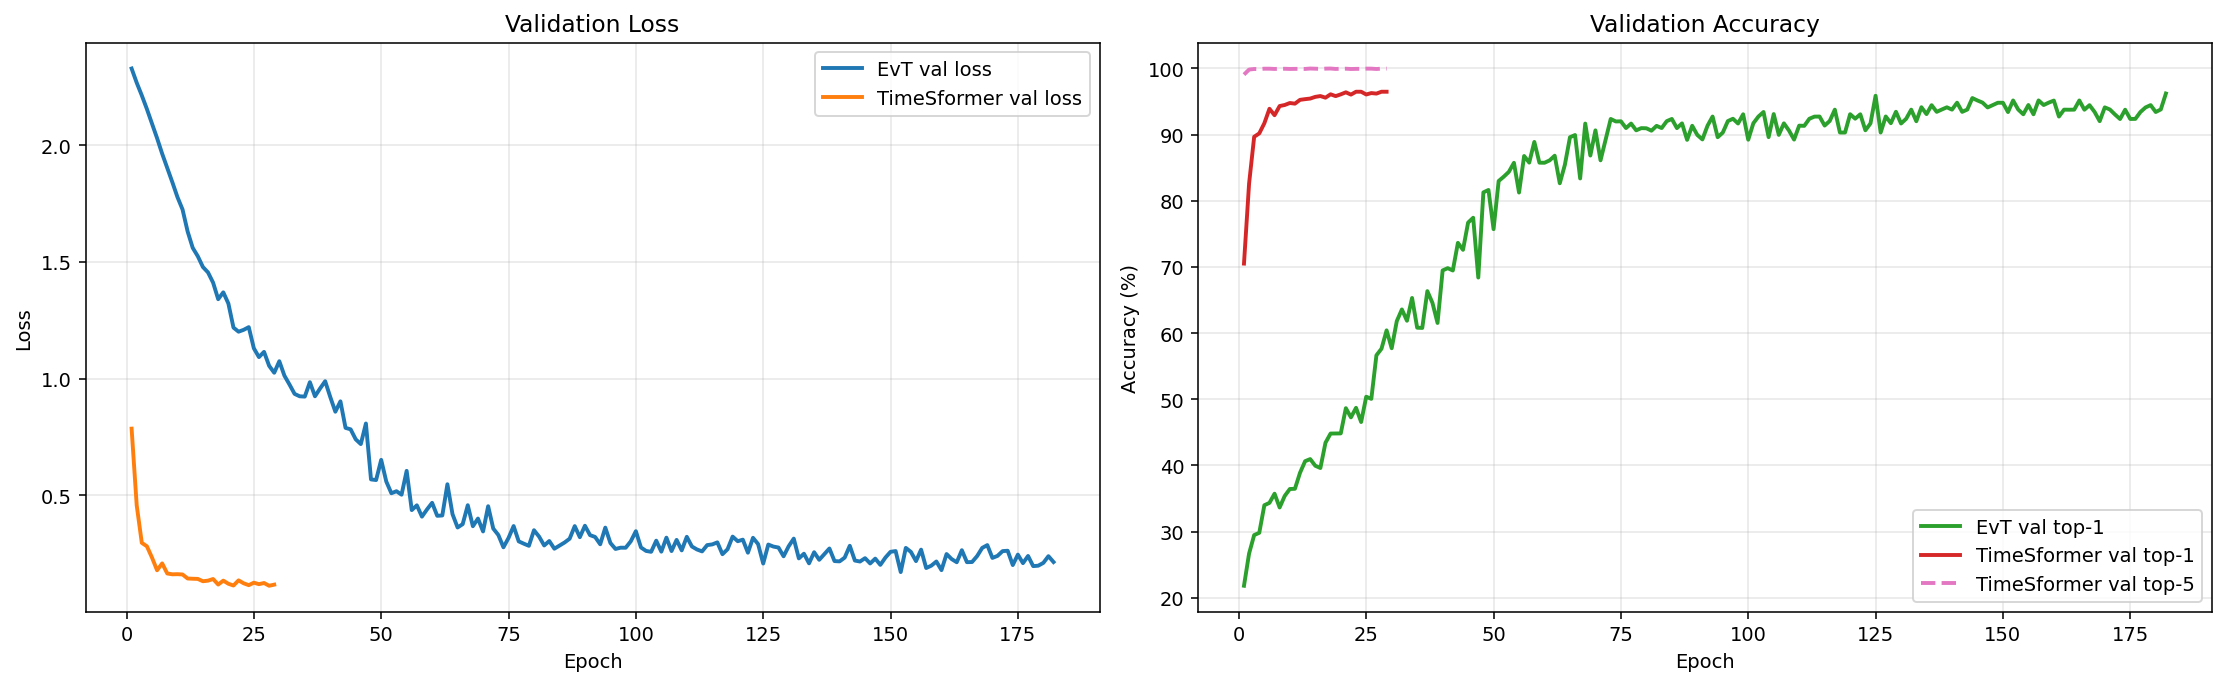

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), dpi=140)

axes[0].plot(evt_val_curve['epoch'], evt_val_curve['val_loss_total'], label='EvT val loss', color='tab:blue', linewidth=2)
if 'loss' in ts_val_epoch.columns:
    axes[0].plot(ts_val_epoch['epoch_idx'], ts_val_epoch['loss'], label='TimeSformer val loss', color='tab:orange', linewidth=2)
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(evt_val_curve['epoch'], evt_val_curve['val_top1_acc'], label='EvT val top-1', color='tab:green', linewidth=2)
if 'val_top5_acc' in evt_val_curve.columns:
    axes[1].plot(evt_val_curve['epoch'], evt_val_curve['val_top5_acc'], label='EvT val top-5', color='tab:olive', linestyle='--', linewidth=2)
axes[1].plot(ts_val_epoch['epoch_idx'], ts_val_epoch['val_top1_acc'], label='TimeSformer val top-1', color='tab:red', linewidth=2)
axes[1].plot(ts_val_epoch['epoch_idx'], ts_val_epoch['val_top5_acc'], label='TimeSformer val top-5', color='tab:pink', linestyle='--', linewidth=2)
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Shared-test confusion matrices

This is where the fair comparison becomes concrete at class level.

Both matrices below are computed on the same test split, so differences here are directly meaningful.

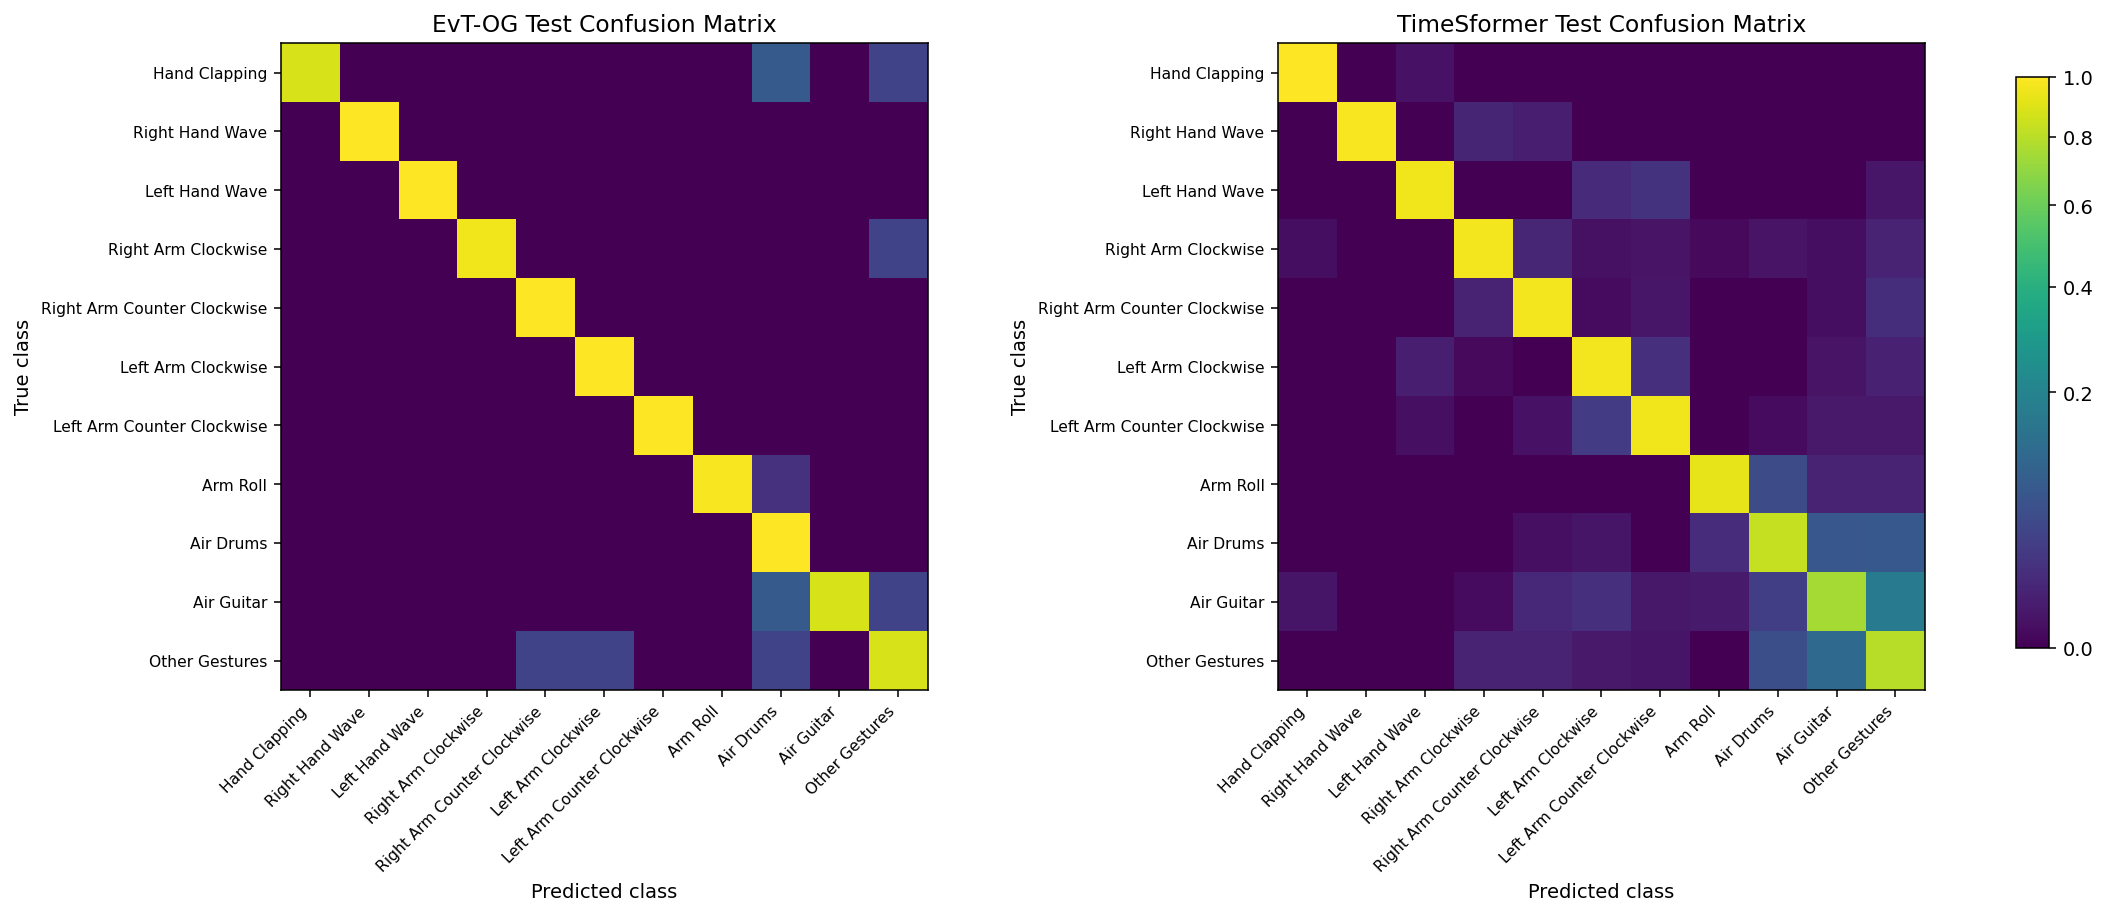

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=140)

for ax, title, cm_df in [
    (axes[0], 'EvT-OG Test Confusion Matrix', evt_test_eval['confusion_matrix']),
    (axes[1], 'TimeSformer Test Confusion Matrix', ts_test_eval['confusion_matrix']),
]:
    im = ax.imshow(cm_df.values, cmap='viridis', norm=colors.PowerNorm(gamma=0.5, vmin=0.0, vmax=1.0))
    ax.set_title(title)
    ax.set_xticks(range(len(cm_df.columns)))
    ax.set_yticks(range(len(cm_df.index)))
    ax.set_xticklabels(cm_df.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(cm_df.index, fontsize=8)
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')
    ax.set_aspect('equal')

fig.subplots_adjust(right=0.90, wspace=0.35)
cbar_ax = fig.add_axes([0.92, 0.16, 0.015, 0.68])
fig.colorbar(im, cax=cbar_ax)
plt.show()

## 8. Per-class recall on the shared test split

A confusion matrix is visually useful, but a per-class recall table is easier to cite and discuss in writing. The values below come from the diagonal of the normalized test confusion matrices.

In [9]:
per_class_df = pd.DataFrame({
    'class': DISPLAY_CLASS_NAMES,
    'EvT recall (%)': np.diag(evt_test_eval['confusion_matrix'].values) * 100.0,
    'TimeSformer recall (%)': np.diag(ts_test_eval['confusion_matrix'].values) * 100.0,
})
per_class_df['EvT minus TimeSformer (pp)'] = per_class_df['EvT recall (%)'] - per_class_df['TimeSformer recall (%)']
display(per_class_df.sort_values('EvT minus TimeSformer (pp)', ascending=False).reset_index(drop=True))

,class,EvT recall (%),TimeSformer recall (%),EvT minus TimeSformer (pp)
0,Air Drums,100.0,83.141447,16.858553
1,Air Guitar,88.0,75.170068,12.829932
2,Other Gestures,88.0,79.885714,8.114286
3,Arm Roll,98.0,92.819040,5.180960
4,Left Arm Counter Clockwise,100.0,95.532915,4.467085
5,Left Hand Wave,100.0,96.103896,3.896104
6,Left Arm Clockwise,100.0,96.159420,3.840580
7,Right Arm Counter Clockwise,100.0,96.727549,3.272451
8,Right Hand Wave,100.0,98.250219,1.749781
9,Right Arm Clockwise,96.0,96.829590,-0.829590


## 9. Resource and efficiency summary

This table collects the resource-oriented statistics that are available from the current codebase and checkpoints.

- **EvT-OG FLOPs** and **activated patches** are measured directly from active sparse windows.
- **TimeSformer FLOPs** are left empty here because they are not currently measured by this benchmark code path.
- Latency is reported per processed sample unit used by each model:
  - EvT: per time-window
  - TimeSformer: per clip

In [10]:
resource_df = pd.DataFrame([
    {
        'Model': 'EvT-OG',
        'Params (M)': evt_test_eval['params_m'],
        'FLOPs (G)': evt_test_eval['flops_g'],
        'Activated patches': evt_test_eval['activated_patches'],
        'Latency on test (ms)': evt_test_eval['latency_ms'],
        'Peak GPU mem (GB)': evt_test_eval['peak_gpu_mem_gb'],
        'Test top-1 acc (%)': evt_test_eval['top1_acc'],
        'Test top-5 acc (%)': evt_test_eval['top5_acc'],
    },
    {
        'Model': 'TimeSformer',
        'Params (M)': ts_test_eval['params_m'],
        'FLOPs (G)': ts_test_eval['flops_g'],
        'Activated patches': ts_test_eval['activated_patches'],
        'Latency on test (ms)': ts_test_eval['latency_ms'],
        'Peak GPU mem (GB)': ts_test_eval['peak_gpu_mem_gb'],
        'Test top-1 acc (%)': ts_test_eval['top1_acc'],
        'Test top-5 acc (%)': ts_test_eval['top5_acc'],
    },
])
display(resource_df)

,Model,Params (M),FLOPs (G),Activated patches,Latency on test (ms),Peak GPU mem (GB),Test top-1 acc (%),Test top-5 acc (%)
0,EvT-OG,0.493355,0.084803,47.804307,0.646254,0.007700,96.333333,99.666667
1,TimeSformer,121.165835,NaN,NaN,4.729021,0.551309,92.208612,99.943995


## 10. Benchmark interpretation

The notebook now contains the pieces needed for a fair benchmark discussion:

- **shared-test top-1 and top-5 accuracy** for both models;
- **validation and test post-hoc evaluation** for both models;
- **test confusion matrices** for both models;
- **validation loss and validation accuracy curves** from the available logs;
- **resource statistics** where the current code supports them.

## Final conclusion

> **Benchmark conclusion.** This comparison is **reasonably fair, but not perfectly apples-to-apples**. It is fair in the most important benchmark sense because **both models are evaluated on the same DVS128 task and on the same final test split**, so the reported shared-test accuracy numbers are directly comparable. However, the pipelines are not identical: **EvT-OG** operates on a native event representation, while **TimeSformer** operates on **E2VID-reconstructed PNG clips** derived from the same event data. This means the comparison is best interpreted as a comparison between **two valid modeling strategies for the same dataset** rather than a pure architecture-only comparison under identical inputs.

> **Accuracy conclusion.** On the shared test split, **EvT-OG remains the stronger top-1 classifier** with **96.33% top-1 accuracy**, while the improved **TimeSformer early-stopping run reaches 92.21% top-1 accuracy**. The gap is therefore about **4.12 percentage points** in favor of EvT-OG. For **top-5 accuracy**, the models are both extremely strong and TimeSformer is slightly higher (**99.94%** vs **99.67%**), but for gesture recognition the main headline metric is normally **top-1**, so the overall classification winner on the shared test split is still **EvT-OG**.

> **Training and generalization conclusion.** The new TimeSformer fine-tuning run is clearly better than the earlier 10-epoch baseline and the training process behaved well: validation improved for a long period, early stopping triggered normally, and there is no sign of catastrophic instability. There is still a visible validation-to-test gap for TimeSformer, so generalization is improved but not perfect. In contrast, EvT-OG continues to show the strongest final test performance on this event-camera benchmark.

> **Efficiency conclusion.** The resource comparison should be interpreted more carefully than the accuracy comparison. EvT-OG has measured sparse-model quantities such as **activated patches** and **FLOPs over active windows**, while TimeSformer is evaluated mainly through clip-level latency, parameter count, and memory. In addition, the latency units are not exactly the same: **EvT-OG latency is measured per time-window**, whereas **TimeSformer latency is measured per clip**. Therefore, the efficiency section is still informative, but it is **less strictly fair than the shared-test accuracy comparison**.

> **Overall thesis takeaway.** For DVS128, this benchmark supports the conclusion that **event-native modeling is still the best-performing choice for top-1 gesture recognition accuracy**, while the frame-based TimeSformer pipeline becomes much more competitive after proper fine-tuning and early stopping. So the final benchmark is strong enough to support a defensible discussion: **the comparison is fair at the dataset-and-test-split level, limited at the input-representation level, and the final top-1 winner is EvT-OG.**